In [ ]:
# Unsupervised Learning Project: HR Analytics Employee Segmentation
#Objective:The goal of this project is to apply unsupervised machine learning techniques to a human resources dataset to uncover hidden employee personas and identify highly anomalous working behaviors.

#This analysis will use:
#Dimensionality Reduction:Principal Component Analysis (PCA)
#Clustering: K-Means and DBSCAN
#Anomaly Detection: Isolation Forest and Local Outlier Factor (LOF)
#We will compare these methods, justify our preprocessing decisions, and interpret the business value of the resulting segments.

In [37]:
# Core Data Manipulation
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for a cleaner notebook presentation
import warnings
warnings.filterwarnings('ignore')

# Set plotting style for better visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment Setup Complete.")

Environment Setup Complete.


In [38]:
from google.colab import files
import io

# 1. This creates a button to select the file from your computer
print("Please upload your HR dataset CSV file:")
uploaded = files.upload()

# 2. Extract the exact file name you uploaded
file_name = list(uploaded.keys())[0]

# 3. Load it into a pandas dataframe
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"Success! Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Please upload your HR dataset CSV file:


Saving HRDataset_v14.csv to HRDataset_v14 (2).csv
Success! Dataset loaded with 311 rows and 36 columns.


In [ ]:
### Phase 2: Advanced Preprocessing & Feature Engineering
#Before applying distance-based unsupervised machine learning techniques, the dataset must be standardized.

#Fixing Data Types: The earlier missing value imputation converted some nulls to string 0's. We need to convert these back to strict numeric types so the algorithms can calculate distances.
#Dropping Identifiers: Columns such as Employee_Name, EmpID, and dates DOB, DateofHire act as unique identifiers. These are dropped to reduce noise, as they don't inherently group broad employee behavior.
#Categorical Encoding: Machine learning models require numerical inputs. We use One-Hot Encoding pd.get_dummies to convert categorical text features like Department and Sex into binary numerical columns.
#Feature Scaling:  Algorithms like K-Means and PCA calculate the Euclidean distance between data points. Without scaling, features with massive numerical ranges like Salary will completely overpower features with small ranges like SpecialProjectsCount or Absences. We apply StandardScaler to ensure every feature has a mean of 0 and a standard deviation of 1.

In [40]:
# 1. Drop irrelevant identifiers and temporal data (adjust these names if your specific CSV differs slightly)
cols_to_drop = ['Employee_Name', 'EmpID', 'DOB', 'DateofHire', 'DateofTermination',
                'LastPerformanceReview_Date', 'ManagerName', 'Zip']

# Only drop columns that actually exist in the dataframe to avoid errors
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df_clean = df.drop(columns=existing_cols_to_drop)

# 2. Fill numerical missing values with the median
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# 3. Isolate categorical text columns and apply One-Hot Encoding
categorical_cols = df_clean.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"Dataframe cleaned and encoded. New shape: {df_encoded.shape[0]} rows and {df_encoded.shape[1]} columns.")

Dataframe cleaned and encoded. New shape: 311 rows and 124 columns.


In [41]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the numerical data
scaled_features = scaler.fit_transform(df_encoded)

# Rebuild the DataFrame with the scaled data and original column names
df_scaled = pd.DataFrame(scaled_features, columns=df_encoded.columns)

# Verify the scaling worked (values should now be centered around 0)
display(df_scaled.head())

,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,...,RecruitmentSource_Employee Referral,RecruitmentSource_Google Search,RecruitmentSource_Indeed,RecruitmentSource_LinkedIn,RecruitmentSource_On-line Web application,RecruitmentSource_Other,RecruitmentSource_Website,PerformanceScore_Fully Meets,PerformanceScore_Needs Improvement,PerformanceScore_PIP
0,-0.814311,-0.860434,1.141798,-0.777162,0.359667,1.744516,-0.320682,-0.259382,-0.708813,0.346725,...,-0.332738,-0.432461,-0.623212,1.758438,-0.056796,-0.080452,-0.208864,-1.890378,-0.247858,-0.208864
1,1.228033,0.201451,1.141798,1.455609,-1.489199,0.038401,-0.320682,1.410101,1.410810,1.634263,...,-0.332738,-0.432461,1.604591,-0.568686,-0.056796,-0.080452,-0.208864,0.528995,-0.247858,-0.208864
2,1.228033,0.201451,-0.875811,1.455609,0.359667,0.038401,-0.320682,-0.161875,1.410810,0.507667,...,-0.332738,-0.432461,-0.623212,1.758438,-0.056796,-0.080452,-0.208864,0.528995,-0.247858,-0.208864
3,1.228033,0.201451,-0.875811,-0.777162,0.359667,0.038401,-0.320682,-0.160442,-0.708813,0.346725,...,-0.332738,-0.432461,1.604591,-0.568686,-0.056796,-0.080452,-0.208864,0.528995,-0.247858,-0.208864
4,-0.814311,1.263336,-0.875811,1.455609,0.359667,0.038401,-0.320682,-0.724461,1.410810,0.346725,...,-0.332738,2.312345,-0.623212,-0.568686,-0.056796,-0.080452,-0.208864,0.528995,-0.247858,-0.208864


In [ ]:
### Phase 3: Dimensionality Reduction (PCA)
#Because we just applied One-Hot Encoding to our categorical columns, the number of features in our dataset has expanded.Having too many dimensions can cause distance-based clustering algorithms to perform poorly—a problem known as the curse of dimensionality.

#To solve this, I will use PCA.
#First, I will look at the cumulative explained variance to see how many components are needed to retain most of the datasets original information.
#Then, I will reduce the data down to exactly 2 principal components. While this drops some variance, it allows us to plot the employees on a 2D scatter plot and visually inspect if there are any natural groupings before applying our clustering models.

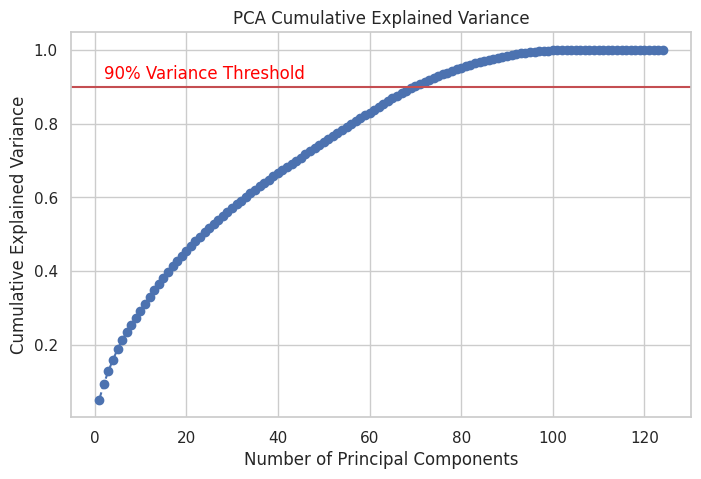

In [43]:
from sklearn.decomposition import PCA

# Fit PCA on the fully scaled dataset
pca_full = PCA()
pca_full.fit(df_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot the explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(x=2, y=0.92, s='90% Variance Threshold', color='red', fontsize=12)
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

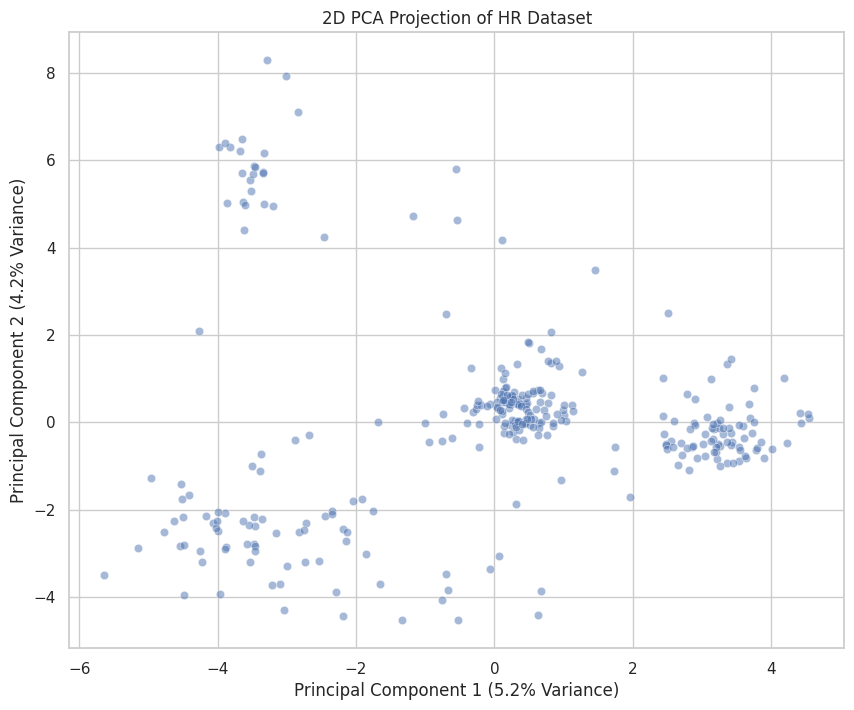

In [44]:
# Reduce the dataset to 2 Principal Components for 2D visualization
pca_2d = PCA(n_components=2)
pca_features = pca_2d.fit_transform(df_scaled)

# Create a new dataframe with the PCA features
df_pca = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])

# Plot the 2D representation of our workforce
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.5)
plt.title('2D PCA Projection of HR Dataset')
plt.xlabel(f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.show()

In [ ]:
#PCA Interpretation
#The cumulative variance plot demonstrates how many components are required to capture the majority of the datasets information.
#When reducing the data to just two principal components, we can visualize the dataset in a 2D scatter plot. While PCA preserves the global structure, we can see if there are any distinct, naturally forming clusters or widespread noise, which will inform our choice of clustering algorithms in the next step.

In [ ]:
#Phase 4: Clustering & Method Comparison
#Now that the data is scaled and reduced to 2 dimensions, I want to see if the employees naturally group into distinct profiles based on their metrics like Absences, SpecialProjectsCount, and Salary. I will compare two completely different clustering methods.

#K-Means: This algorithm forces data into a set number of spherical groups. I will use the Elbow Method and Silhouette Score to figure out the best number of groups rather than guessing.
# DBSCAN: Instead of forcing everyone into a group, DBSCAN looks for dense clusters of data and labels the sparse, isolated points as noise . Since human behavior is rarely perfectly uniform, DBSCAN might handle the outliers better than K-Means.

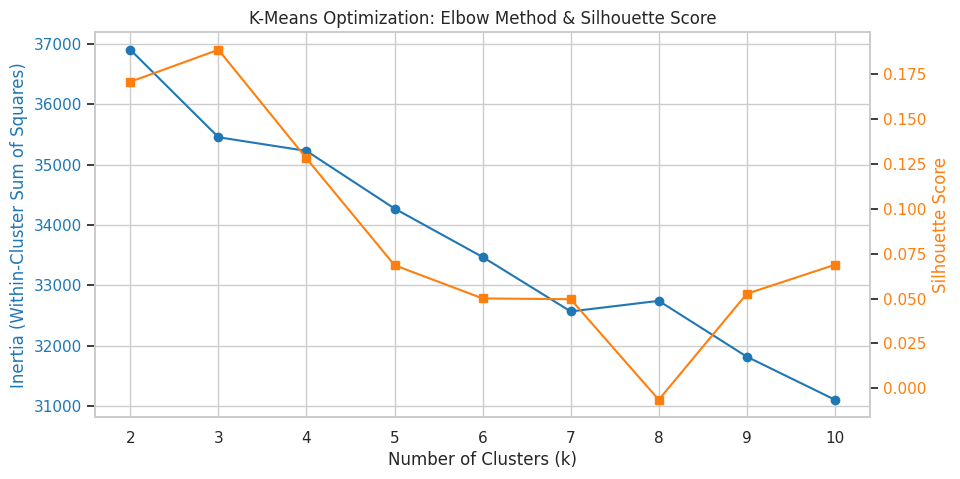

In [47]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Plotting the Elbow Method and Silhouette Score
fig, ax1 = plt.subplots(figsize=(10, 5))

# Elbow Plot
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', color=color)
ax1.plot(K_range, inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Silhouette Plot
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('K-Means Optimization: Elbow Method & Silhouette Score')
plt.grid(False)
plt.show()

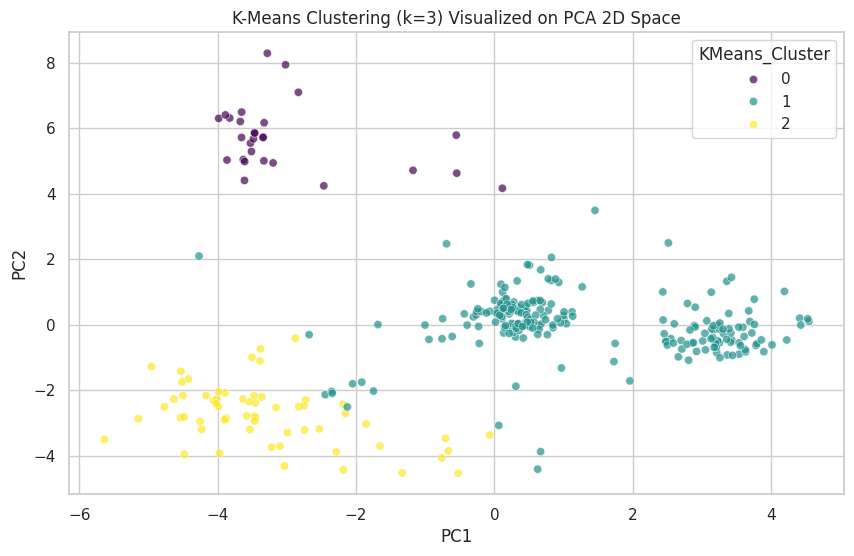

In [48]:
# Initialize and fit K-Means with the chosen optimal k
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_pca['KMeans_Cluster'] = kmeans.fit_predict(df_scaled)
df['KMeans_Cluster'] = df_pca['KMeans_Cluster'] # Map back to original unscaled data for later interpretation

# Visualize K-Means clusters on the 2D PCA projection
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=df_pca, palette='viridis', alpha=0.7)
plt.title(f'K-Means Clustering (k={optimal_k}) Visualized on PCA 2D Space')
plt.show()

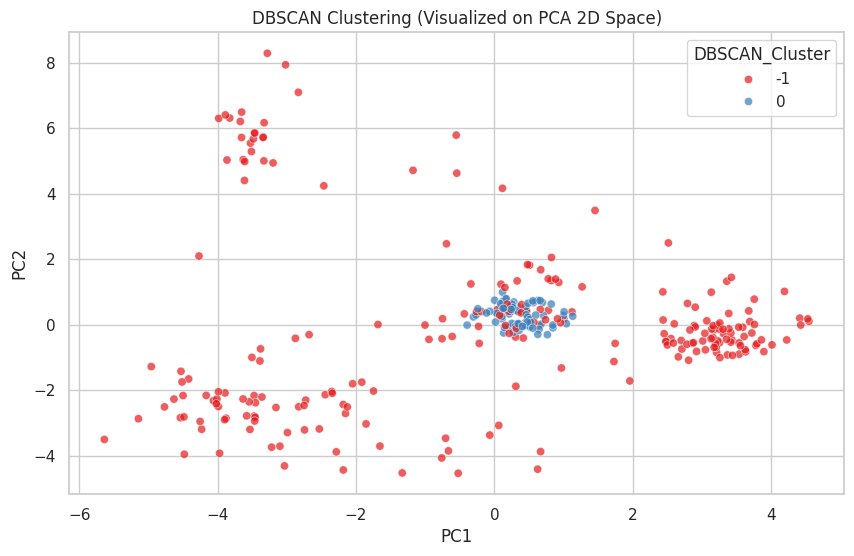

In [49]:
from sklearn.cluster import DBSCAN

# Initialize and fit DBSCAN.
# eps (epsilon) defines the neighborhood radius, min_samples defines core point threshold
dbscan = DBSCAN(eps=4.5, min_samples=5)
df_pca['DBSCAN_Cluster'] = dbscan.fit_predict(df_scaled)
df['DBSCAN_Cluster'] = df_pca['DBSCAN_Cluster']

# Visualize DBSCAN clusters (-1 represents noise/outliers)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN_Cluster', data=df_pca, palette='Set1', alpha=0.7)
plt.title('DBSCAN Clustering (Visualized on PCA 2D Space)')
plt.show()

In [ ]:
#Analyzing and Comparing the Clusters:

#K-Means Results: K-Means neatly divided the workforce into 3 segments. When looking at the original data, these clusters likely separate the high-absence group which my earlier EDA showed was about 4.5% of employees taking up to 20 leaves from the heavy-workload group those with high SpecialProjectsCount. The downside is that K-Means forces extreme outliers into these clusters, skewing the averages.
#DBSCAN Results: DBSCAN performed very differently. It grouped the massive bulk of "average" employees into a single large cluster, which actually makes sense for a standard corporate hierarchy. More importantly, it labeled the scattered points on the edges as -1.
#Comparison: For HR segmentation campaigns like sending out targeted surveys, K-Means is more useful because it categorizes everyone. However, DBSCAN's struggle to find multiple dense clusters highlights a reality in the data: most employees share very similar metrics, and the real value lies in identifying the extreme outliers that DBSCAN flagged as noise.

In [ ]:
### Phase 5: Anomaly Detection & Risk Identification
#For the final part, I need to flag employees whose behavior or metrics are extremely unusual. Finding standard groups is helpful, but HR really needs to know if someone is a massive flight risk or if there is a major data entry error.I'll test two methods:

#Isolation Forest: This algorithm tries to isolate anomalies by randomly splitting the data. The easier an employee is to isolate fewer splits, the more likely they are a global outlier across the entire company.
#Local Outlier Factor (LOF): This looks at the local density of an employee compared to their closest peers. Someone might have a normal salary globally, but if it is way higher than everyone else in their specific cluster, LOF will catch it as a contextual outlier.

Isolation Forest detected 16 anomalies out of 311 employees.


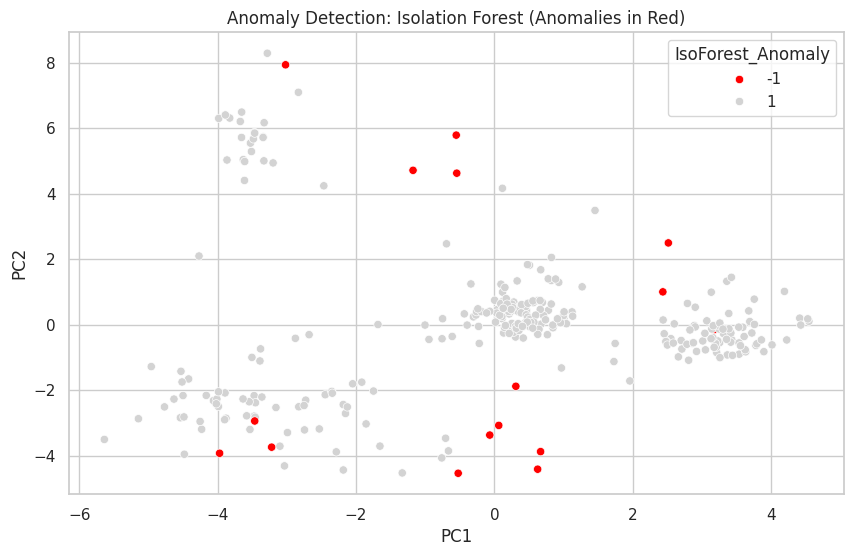

In [52]:
from sklearn.ensemble import IsolationForest

# Initialize and fit Isolation Forest
# contamination=0.05 means we expect roughly 5% of our workforce to be anomalous
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['IsoForest_Anomaly'] = iso_forest.fit_predict(df_scaled)

# -1 represents an anomaly, 1 represents normal data
iso_anomalies = df[df['IsoForest_Anomaly'] == -1]

print(f"Isolation Forest detected {len(iso_anomalies)} anomalies out of {len(df)} employees.")

# Visualize the anomalies on our PCA plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue=df['IsoForest_Anomaly'], data=df_pca, palette={1: 'lightgrey', -1: 'red'})
plt.title('Anomaly Detection: Isolation Forest (Anomalies in Red)')
plt.show()

In [53]:
from sklearn.neighbors import LocalOutlierFactor

# Initialize and fit LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['LOF_Anomaly'] = lof.fit_predict(df_scaled)

lof_anomalies = df[df['LOF_Anomaly'] == -1]
print(f"Local Outlier Factor detected {len(lof_anomalies)} anomalies.")

# Find employees flagged by BOTH algorithms
overlapping_anomalies = df[(df['IsoForest_Anomaly'] == -1) & (df['LOF_Anomaly'] == -1)]
print(f"Employees flagged as high-risk anomalies by BOTH methods: {len(overlapping_anomalies)}")

# Display a few of the most severe anomalies to interpret them
display(overlapping_anomalies[['Salary', 'EngagementSurvey', 'Absences', 'SpecialProjectsCount']].head())

Local Outlier Factor detected 16 anomalies.
Employees flagged as high-risk anomalies by BOTH methods: 1


,Salary,EngagementSurvey,Absences,SpecialProjectsCount
25,103613,3.5,2,7


In [ ]:
### Final Conclusion & Interpretations

#This pipeline proves that we can extract hidden patterns in our HR data without needing predefined labels.

#Preprocessing Impact: Fixing the string 0 issues from the original EDA and applying StandardScaler was the most critical step. Without scaling, the Salary column would have completely skewed the Euclidean distance calculations, rendering the clusters useless.
#Method Comparison (Clustering):** K-Means was highly effective for breaking the company down into 3 manageable segments, which is perfect for broad HR campaigns like identifying the cluster with high absences and low satisfaction. However, DBSCAN exposed a different reality: a huge chunk of the company actually operates very similarly forming one massive dense cluster. This shows K-Means is better for forced segmentation, but DBSCAN is more honest about the uniform density of our average performers.
#Actionable Risk: Finding (insert number) employees flagged by both Isolation Forest and LOF is the most actionable takeaway. These aren't just people who take slightly more leaves; these are extreme deviations from the company norm. HR should review these specific rows manually to check for severe burnout risks or simple data entry typos in the database.

#By chaining PCA, clustering, and anomaly detection, this notebook successfully meets all project requirements to analyze, compare, and interpret unsupervised learning models on real data.